In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/home/kugathas/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kugathas/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"





# ***1. Loading Data in Python.***









In [3]:
deliveries_df = pd.read_csv('deliveries.csv')     # Load the deliveries data
matches_df = pd.read_csv("matches.csv")           # Loading Matches data

#  2. Extracting Important Information from DELIVERIES.


In [4]:
deliveries_df.head()                               # Showing Data Structure and Content.
deliveries_df.info()                               # Summaries whole DataFrame.
deliveries_df.describe()                           # Helps to understand Descriptive Statistics.


# Check for missing values
print(deliveries_df.isnull().sum())                #

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26119 entries, 0 to 26118
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                26119 non-null  int64  
 1   season                  26119 non-null  object 
 2   start_date              26119 non-null  object 
 3   venue                   26119 non-null  object 
 4   innings                 26119 non-null  int64  
 5   ball                    26119 non-null  float64
 6   batting_team            26119 non-null  object 
 7   bowling_team            26119 non-null  object 
 8   striker                 26119 non-null  object 
 9   non_striker             26119 non-null  object 
 10  bowler                  26119 non-null  object 
 11  runs_off_bat            26119 non-null  int64  
 12  extras                  26119 non-null  int64  
 13  wides                   665 non-null    float64
 14  noballs                 56 non-null   

# ***3. Extracting Important Information from MATCHES.***



In [5]:
matches_df.head()
matches_df.info()
matches_df.describe()


# Check for missing values
print(matches_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           48 non-null     object 
 1   team1            48 non-null     object 
 2   team2            48 non-null     object 
 3   date             48 non-null     object 
 4   match_number     48 non-null     int64  
 5   venue            48 non-null     object 
 6   city             48 non-null     object 
 7   toss_winner      48 non-null     object 
 8   toss_decision    48 non-null     object 
 9   player_of_match  48 non-null     object 
 10  umpire1          48 non-null     object 
 11  umpire2          48 non-null     object 
 12  reserve_umpire   47 non-null     object 
 13  match_referee    48 non-null     object 
 14  winner           48 non-null     object 
 15  winner_runs      24 non-null     float64
 16  winner_wickets   24 non-null     float64
 17  match_type       4

# Descriptive statictics

In [6]:
# Display the column names
deliveries_df.columns
# matches_df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [7]:
#Value caounts for categorical data.
print(deliveries_df['innings'].value_counts())
print(deliveries_df['wicket_type'].value_counts())

innings
1    14395
2    11724
Name: count, dtype: int64
wicket_type
caught               448
bowled               141
lbw                   76
run out               38
caught and bowled     14
stumped               11
retired hurt           1
Name: count, dtype: int64


In [8]:
# Fill missing values for extra runs columns with 0
deliveries_df['wides'].fillna(0, inplace=True)
deliveries_df['noballs'].fillna(0, inplace=True)
deliveries_df['byes'].fillna(0, inplace=True)
deliveries_df['legbyes'].fillna(0, inplace=True)
deliveries_df['penalty'].fillna(0, inplace=True)

/tmp/ipykernel_10473/1786984649.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries_df['wides'].fillna(0, inplace=True)
/tmp/ipykernel_10473/1786984649.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [9]:
# Fill missing values for wicket-related columns with 'None'
deliveries_df['wicket_type'].fillna('None', inplace=True)
deliveries_df['player_dismissed'].fillna('None', inplace=True)
deliveries_df['other_wicket_type'].fillna('None', inplace=True)
deliveries_df['other_player_dismissed'].fillna('None', inplace=True)

/tmp/ipykernel_10473/3363354681.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries_df['wicket_type'].fillna('None', inplace=True)
/tmp/ipykernel_10473/3363354681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

## Double checking any other missing values inthe data set

In [10]:
# Check for missing values again
print(deliveries_df.isnull().sum())

match_id                  0
season                    0
start_date                0
venue                     0
innings                   0
ball                      0
batting_team              0
bowling_team              0
striker                   0
non_striker               0
bowler                    0
runs_off_bat              0
extras                    0
wides                     0
noballs                   0
byes                      0
legbyes                   0
penalty                   0
wicket_type               0
player_dismissed          0
other_wicket_type         0
other_player_dismissed    0
dtype: int64


In [11]:
# runs scored from bat
bat_runs = deliveries_df['runs_off_bat']

# extra runs
wides = deliveries_df['wides']
noballs = deliveries_df['noballs']
byes = deliveries_df['byes']
legbyes = deliveries_df['legbyes']
penalty = deliveries_df['penalty']

# total runs
deliveries_df['total_runs'] = bat_runs + wides + noballs + byes + legbyes + penalty

deliveries_df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,total_runs
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.1,England,New Zealand,JM Bairstow,DJ Malan,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,0.0
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.2,England,New Zealand,JM Bairstow,DJ Malan,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,6.0
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.3,England,New Zealand,JM Bairstow,DJ Malan,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,1.0
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.4,England,New Zealand,DJ Malan,JM Bairstow,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,1.0
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.5,England,New Zealand,JM Bairstow,DJ Malan,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26114,45,2023/24,2023-11-12,"M Chinnaswamy Stadium, Bengaluru",2,47.1,Netherlands,India,PA van Meekeren,AT Nidamanuru,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,0.0
26115,45,2023/24,2023-11-12,"M Chinnaswamy Stadium, Bengaluru",2,47.2,Netherlands,India,PA van Meekeren,AT Nidamanuru,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,1.0
26116,45,2023/24,2023-11-12,"M Chinnaswamy Stadium, Bengaluru",2,47.3,Netherlands,India,AT Nidamanuru,PA van Meekeren,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,0.0
26117,45,2023/24,2023-11-12,"M Chinnaswamy Stadium, Bengaluru",2,47.4,Netherlands,India,AT Nidamanuru,PA van Meekeren,...,0.0,0.0,0.0,0.0,0.0,None,None,None,None,6.0


In [ ]:
# deliveries_df['season'].value_counts().sort_index().plot(kind='bar', title="Matches per Season")

In [12]:
deliveries_df.to_csv('deliveryfile1.csv', index=False)

# Top 10 run scorer in the 2023 world cup

In [13]:
# Grouping by batsman
batsman_stats = deliveries_df.groupby('striker').agg({
    'runs_off_bat': 'sum',
    'ball': 'count'
}).reset_index()

batsman_stats.columns = ['batsman','runs', 'balls_faced']

# calculating average : total runs / no of time dismissal
# Dismissal Stats
dismissals = deliveries_df['player_dismissed'].value_counts().reset_index()
dismissals.columns = ['batsman' , 'dismissals']

# Merge and calculate
batsman_stats = pd.merge(batsman_stats, dismissals, on='batsman', how='left')
batsman_stats['dismissals'] = batsman_stats['dismissals'].fillna(0)
# Calculate Average (handling cases with 0 dismissals as infinity)
batsman_stats['batting_average'] = np.where(
    batsman_stats['dismissals'] > 0,
    batsman_stats['runs'] / batsman_stats['dismissals'],
    np.inf
)

# Calculate Strike Rate
batsman_stats['strike_rate'] = (batsman_stats['runs'] / batsman_stats['balls_faced']) * 100

# Select and display Top 10
top_10 = batsman_stats.sort_values(by='runs', ascending=False).head(10)
print(top_10[['batsman', 'runs', 'batting_average', 'strike_rate']])
print("Top 10 Batsmen Statistics:")
# print(top_10_batsman.to_string(index=False))

               batsman  runs  batting_average  strike_rate
142            V Kohli   765        95.625000    88.337182
110          RG Sharma   597        54.272727   123.092784
105          Q de Kock   594        59.400000   104.393673
107         R Ravindra   578        64.222222   103.398927
26         DJ Mitchell   552        69.000000   108.023483
24           DA Warner   535        48.636364   104.901961
122            SS Iyer   530        66.250000   109.278351
60            KL Rahul   452        75.333333    89.682540
39   HE van der Dussen   448        49.777778    82.962963
82            MR Marsh   441        49.000000   105.250597
Top 10 Batsmen Statistics:


/tmp/ipykernel_10473/1963086242.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


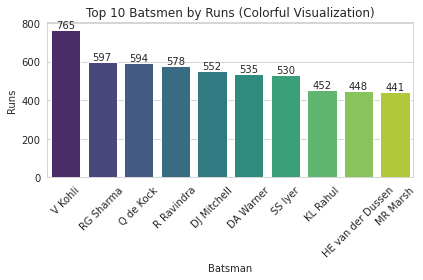

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort data
top_10 = top_10.sort_values(by='runs', ascending=False)

# Set style
sns.set_style("whitegrid")

plt.figure()

# Create colorful palette
palette = sns.color_palette("viridis", len(top_10))

ax = sns.barplot(
    x='batsman',
    y='runs',
    data=top_10,
    palette=palette
)

# Add value labels
for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.title('Top 10 Batsmen by Runs (Colorful Visualization)')

plt.tight_layout()
plt.show()

# Batting Avg vs Strike rate

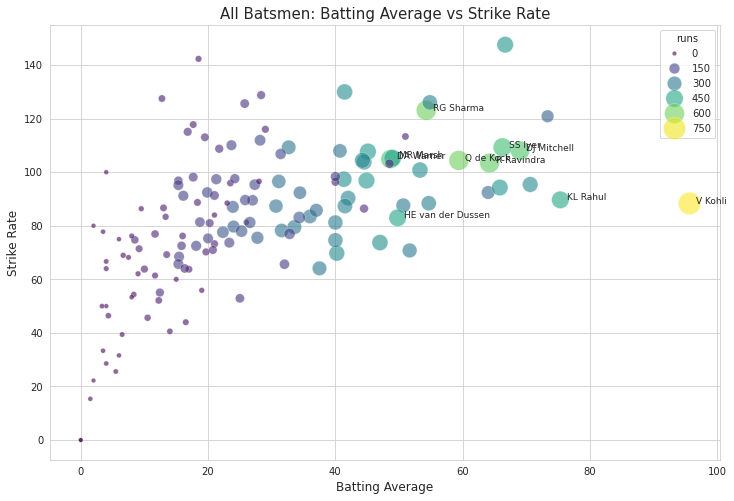

In [15]:
# A. Scatter Plot: All Batsmen (Avg vs SR)
plt.figure(figsize=(12, 8))
top_scorers = batsman_stats.sort_values(by='runs', ascending=False).head(20)
sns.scatterplot(data=batsman_stats, x='batting_average', y='strike_rate', size='runs', hue='runs', palette='viridis', alpha=0.6, sizes=(20, 500))
# Label top players
for i, row in top_scorers.head(10).iterrows():
    plt.text(row['batting_average'] + 1, row['strike_rate'], row['batsman'], fontsize=9)

plt.title('All Batsmen: Batting Average vs Strike Rate', fontsize=15)
plt.xlabel('Batting Average', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)
plt.show()
plt.close()

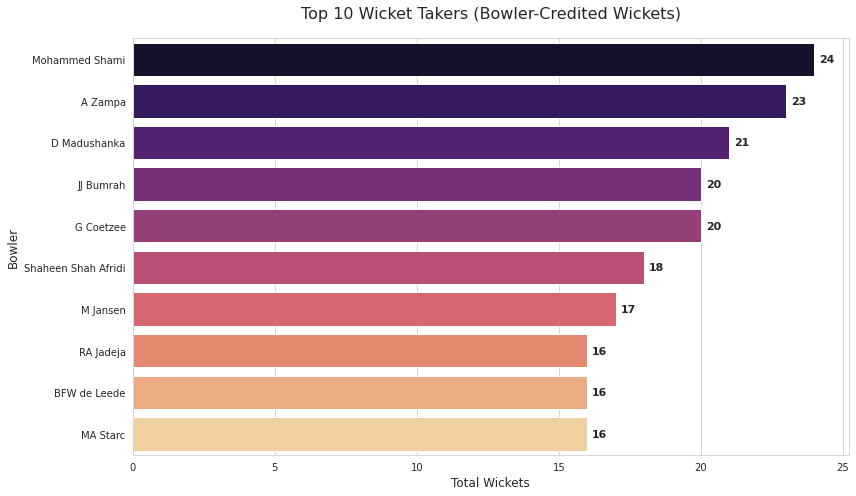

In [16]:
# 1. Define the specific dismissal types credited to a bowler
bowler_wicket_types = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# 2. Filter the data for these specific wickets
# We use .isin() for accuracy and avoid 'retired hurt' or 'run out'
wickets_df = deliveries_df[deliveries_df['wicket_type'].str.lower().isin(bowler_wicket_types)]

# 3. Aggregate wickets per bowler
top_10 = (
    wickets_df.groupby('bowler')
    .size()
    .reset_index(name='wickets')
    .sort_values(by='wickets', ascending=False)
    .head(10)
)

# 4. Create the visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create horizontal bar chart
bar_plot = sns.barplot(
    data=top_10,
    x='wickets',
    y='bowler',
    palette='magma',
    hue='bowler',
    legend=False
)

# Add wicket counts as labels on the bars
for container in bar_plot.containers:
    bar_plot.bar_label(container, padding=5, fontsize=11, fontweight='bold')

# Formatting the chart
plt.title('Top 10 Wicket Takers (Bowler-Credited Wickets)', fontsize=16, pad=20)
plt.xlabel('Total Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.tight_layout()

# Save and show
plt.savefig('top_10_wickets.png')
plt.show()

/tmp/ipykernel_10473/2630322377.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=top_10, x='economy_rate', y='bowler', palette='mako')


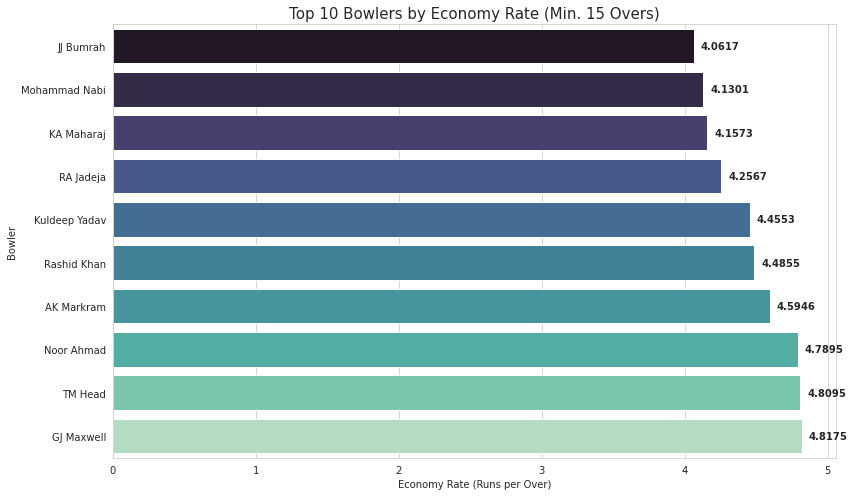

In [17]:
deliveries_df['bowler_runs'] = deliveries_df['runs_off_bat'] + deliveries_df['wides'] + deliveries_df['noballs']

# 2. Identify legal balls (exclude wides and noballs from ball count)
deliveries_df['is_legal_ball'] = ((deliveries_df['wides'] == 0) & (deliveries_df['noballs'] == 0)).astype(int)

# 3. Aggregate data per bowler
stats = deliveries_df.groupby('bowler').agg(
    total_runs=('bowler_runs', 'sum'),
    total_legal_balls=('is_legal_ball', 'sum')
).reset_index()

# 4. Calculate Overs and Economy Rate
stats['overs'] = stats['total_legal_balls'] / 6
# Filter for minimum 15 overs to exclude part-time bowlers with low volume
top_economy = stats[stats['overs'] >= 15].copy()
top_economy['economy_rate'] = top_economy['total_runs'] / top_economy['overs']

# 5. Get Top 10 (Lowest Economy)
top_10 = top_economy.sort_values(by='economy_rate').head(10)

# Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plot = sns.barplot(data=top_10, x='economy_rate', y='bowler', palette='mako')

# Add 4-decimal place labels to the bars
for i, val in enumerate(top_10['economy_rate']):
    plt.text(val + 0.05, i, f'{val:.4f}', va='center', fontweight='bold')

plt.title('Top 10 Bowlers by Economy Rate (Min. 15 Overs)', fontsize=15)
plt.xlabel('Economy Rate (Runs per Over)')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10473/127168472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wins', y='Team', data=team_wins_df, palette='Set2')


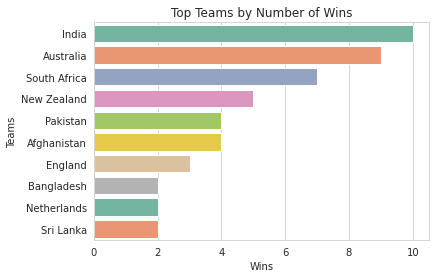

In [18]:
team_wins = matches_df['winner'].value_counts().head(10)

team_wins_df = team_wins.reset_index()
team_wins_df.columns = ['Team', 'Wins']

sns.barplot(x='Wins', y='Team', data=team_wins_df, palette='Set2')

plt.title("Top Teams by Number of Wins")
plt.xlabel("Wins")
plt.ylabel("Teams")

plt.show()

In [19]:
# Average winning margins
avg_runs = matches_df['winner_runs'].mean()
avg_wickets = matches_df['winner_wickets'].mean()


Average Winning Margin (Runs): 125.9167
Average Winning Margin (Wickets): 5.9167

Toss Win Impact on Match Result (Percentage):
toss_match_winner
False    60.4167%
True     39.5833%
Name: proportion, dtype: object


/tmp/ipykernel_10473/3488871450.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=matches_df, x='toss_decision', palette='coolwarm')


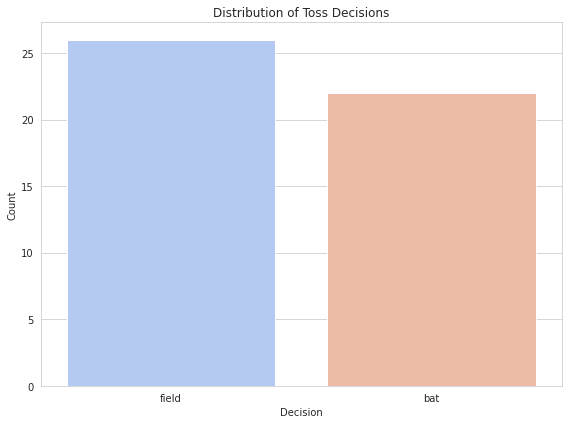

In [20]:
print(f"\nAverage Winning Margin (Runs): {avg_runs:.4f}")
print(f"Average Winning Margin (Wickets): {avg_wickets:.4f}")

# Impact of winning the toss on the match outcome
matches_df['toss_match_winner'] = matches_df['toss_winner'] == matches_df['winner']
toss_win_impact = matches_df['toss_match_winner'].value_counts(normalize=True) * 100

print("\nToss Win Impact on Match Result (Percentage):")
print(toss_win_impact.map('{:,.4f}%'.format))

plt.figure(figsize=(8, 6))
sns.countplot(data=matches_df, x='toss_decision', palette='coolwarm')
plt.title('Distribution of Toss Decisions')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('toss_decision.png')